### Before start, load inference environments, gpu, cuda, ...

In [1]:
from envs import actenv_jupyter, change_exp_dir, make_gpu_mem_reporter
actenv_jupyter(cuda_version="12.5", gcc_version="11", clear_cache=False)

[actenv_jupyter] CUDA_HOME=/usr/local/cuda-12.5
[actenv_jupyter] TORCH_CUDA_ARCH_LIST=8.0
[actenv_jupyter] CXX=/usr/bin/g++-11 | CC=/usr/bin/gcc-11
[actenv_jupyter] Ready.


{'CUDA_HOME': '/usr/local/cuda-12.5',
 'TORCH_CUDA_ARCH_LIST': '8.0',
 'CC': '/usr/bin/gcc-11',
 'CXX': '/usr/bin/g++-11',
 'CUDAHOSTCXX': '/usr/bin/g++-11',
 'CXXFLAGS': '-std=c++17',
 'PATH_head': '/usr/local/cuda-12.5/bin:/home/ids/yuhe/anaconda3/envs/styleGANenv/bin:/home/ids/yuhe/.vscode-server/cli/servers/Stable-c9d77990917f3102ada88be140d28b038d1dd7c7/server/bin/remote-cli',
 'LD_LIBRARY_PATH_head': '/usr/local/cuda-12.5/lib64:',
 'TORCH_CUDA_VERBOSE_BUILD': '1',
 'MAX_JOBS': '1'}

### Set experiment dir and models' paths

In [2]:
import torch
import os
import yaml

root_dir = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN"
sfe_root = "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS"
medminist_path = '/home/ids/yuhe/Projects/CA_with_GAN/2_data/medical_datasets'
med_path = '/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Medical_imaging'

Paths_models = {
    ########################## Octmnist splits ##########################
    "t2f_cs": {
        "stylegan_weights":  "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pretrained_models/stylegan2/stylegan2_medical_images/brats_multiMod_Ros.pt",
        "stylegan_weights_pkl": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/styleGAN_ada/output/brats_multiMod_1gpu/00000-bratsMultiMod-mirror-paper256-ada-blit-resumecustom/network-snapshot-005241.pkl",
        "pSp_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp/results/brats_multiMod_Ros_resume/checkpoints/iteration_540000.pt",
        "inverter_pth": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS/experiments/inverter/brats_multimod/fse_inverter_train_000/iteration_140000.pt",
        #"pSp_cs_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp_CS-StyleGAN/results/bratsMultiMod/t1n_t2f_cs_Reg/checkpoints/iteration_30000.pt",
        "sfe_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS/experiments/fse_cs_editor_train_new/brats_multimod/t1n_t2f_cs_Reg_001/iteration_350000.pt"
    },
    
    "t2f_cs1s2": {
        "stylegan_weights":  "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pretrained_models/stylegan2/stylegan2_medical_images/brats_multiMod_Ros.pt",
        "stylegan_weights_pkl": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/styleGAN_ada/output/brats_multiMod_1gpu/00000-bratsMultiMod-mirror-paper256-ada-blit-resumecustom/network-snapshot-005241.pkl",
        "pSp_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp/results/brats_multiMod_Ros_resume/checkpoints/iteration_540000.pt",
        "inverter_pth": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS/experiments/inverter/brats_multimod/fse_inverter_train_000/iteration_140000.pt",
        #"pSp_cs_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp_CS-StyleGAN/results/BRATSMultiMod/t1n_t2f_Reg_cs1s2/checkpoints/iteration_30000.pt",
        "sfe_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS/experiments/fse_cs_editor_train_new/brats_multimod/t1n_t2f_cs_Reg_c1c2_000/iteration_350000.pt"
    }, 

    "t2w_cs": {
        "stylegan_weights":  "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pretrained_models/stylegan2/stylegan2_medical_images/brats_multiMod_Ros.pt",
        "stylegan_weights_pkl": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/styleGAN_ada/output/brats_multiMod_1gpu/00000-bratsMultiMod-mirror-paper256-ada-blit-resumecustom/network-snapshot-005241.pkl",
        "pSp_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp/results/brats_multiMod_Ros_resume/checkpoints/iteration_540000.pt",
        "inverter_pth": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS/experiments/inverter/brats_multimod/fse_inverter_train_000/iteration_140000.pt",
        #"pSp_cs_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp_CS-StyleGAN/results/bratsMultiMod/t1n_t2w_cs_Reg/checkpoints/iteration_30000.pt",
        "sfe_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS/experiments/fse_cs_editor_train_new/brats_multimod/t1n_t2w_cs_Reg_000/iteration_350000.pt"
    },  
    "t2w_cs1s2": {
        "stylegan_weights":  "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/pretrained_models/stylegan2/stylegan2_medical_images/brats_multiMod_Ros.pt",
        "stylegan_weights_pkl": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/styleGAN_ada/output/brats_multiMod_1gpu/00000-bratsMultiMod-mirror-paper256-ada-blit-resumecustom/network-snapshot-005241.pkl",
        "pSp_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp/results/brats_multiMod_Ros_resume/checkpoints/iteration_540000.pt",
        "inverter_pth": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS/experiments/inverter/brats_multimod/fse_inverter_train_000/iteration_140000.pt",
        #"pSp_cs_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp_CS-StyleGAN/results/BRATSMultiMod/t1n_t2w_Reg_cs1s2/checkpoints/iteration_60000.pt",
        "sfe_path": "/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS/experiments/fse_cs_editor_train_new/brats_multimod/t1n_t2w_cs_Reg_c1c2_000/iteration_380000.pt"
    }, 
    }

Paths_datasets = {
    'brats_multimod_t1c': {
        'train': med_path +'/brats/Preprocessed/train_styleGAN2ada_multiMod',
        'val': med_path +'/brats/Preprocessed/train_styleGAN2ada_multiMod_test',
        'train_bg': med_path + '/brats/X_Y_splits/bratsMultiMod_paired/train_X_t1n.npy',
        'train_t': med_path + '/brats/X_Y_splits/bratsMultiMod_paired/train_Y_t1c.npy',
        'val_bg':  med_path + '/brats/X_Y_splits/bratsMultiMod_paired/test_X_t1n.npy',
        'val_t':  med_path + '/brats/X_Y_splits/bratsMultiMod_paired/test_Y_t1c.npy',
        "special_bg": med_path + '/brats/X_Y_splits/bratsMultiMod_paired/test_X_t1n.npy',
        "special_t":  med_path + '/brats/X_Y_splits/bratsMultiMod_paired/test_Y_t1c.npy',
    },

    'brats_multimod_t2f': {
        'train': med_path +'/brats/Preprocessed/train_styleGAN2ada_multiMod',
        'val': med_path +'/brats/Preprocessed/train_styleGAN2ada_multiMod_test',
        'train_bg': med_path + '/brats/X_Y_splits/bratsMultiMod_paired/train_X_t1n.npy',
        'train_t': med_path + '/brats/X_Y_splits/bratsMultiMod_paired/train_Y_t2f.npy',
        'val_bg':  med_path + '/brats/X_Y_splits/bratsMultiMod_paired/test_X_t1n.npy',
        'val_t':  med_path + '/brats/X_Y_splits/bratsMultiMod_paired/test_Y_t2f.npy',
        "special_bg": med_path + '/brats/X_Y_splits/bratsMultiMod_paired/test_X_t1n.npy',
        "special_t":  med_path + '/brats/X_Y_splits/bratsMultiMod_paired/test_Y_t2f.npy',
    },


    'brats_multimod_t2w': {
        'train': med_path +'/brats/Preprocessed/train_styleGAN2ada_multiMod',
        'val': med_path +'/brats/Preprocessed/train_styleGAN2ada_multiMod_test',
        'train_bg': med_path + '/brats/X_Y_splits/bratsMultiMod_paired/train_X_t1n.npy',
        'train_t': med_path + '/brats/X_Y_splits/bratsMultiMod_paired/train_Y_t2w.npy',
        'val_bg':  med_path + '/brats/X_Y_splits/bratsMultiMod_paired/test_X_t1n.npy',
        'val_t':  med_path + '/brats/X_Y_splits/bratsMultiMod_paired/test_Y_t2w.npy',
        "special_bg": med_path + '/brats/X_Y_splits/bratsMultiMod_paired/test_X_t1n.npy',
        "special_t":  med_path + '/brats/X_Y_splits/bratsMultiMod_paired/test_Y_t2w.npy',
    },
    'brats_multimod_t2f_unpaired':{
            'train': med_path +'/brats/Preprocessed/train_styleGAN2ada_multiMod',
            'val': med_path +'/brats/Preprocessed/train_styleGAN2ada_multiMod_test',
            'train_bg': med_path + '/brats/X_Y_splits/bratsMultiMod_unpaired/train_X_t1n.npy',
            'train_t': med_path + '/brats/X_Y_splits/bratsMultiMod_unpaired/train_Y_t2f.npy',
            'val_bg':  med_path + '/brats/X_Y_splits/bratsMultiMod_unpaired/test_X_t1n.npy',
            'val_t':  med_path + '/brats/X_Y_splits/bratsMultiMod_unpaired/test_Y_t2f.npy',
            "special_bg": med_path + '/brats/X_Y_splits/bratsMultiMod_unpaired/test_X_t1n.npy',
            "special_t":  med_path + '/brats/X_Y_splits/bratsMultiMod_unpaired/test_Y_t2f.npy',
            }, 
    }


change_exp_dir(sfe_root)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model_name = 't2f_cs'
dataset_name = 'brats_multimod_t2f'

sfe_ckpt_path = Paths_models[model_name]["sfe_path"]

# Load config.yaml
config_yaml_path = os.path.join(os.path.dirname(sfe_ckpt_path), "config.yaml")
from omegaconf import OmegaConf
config = OmegaConf.load(config_yaml_path)

config.model.w_space_encoder = "pSp"
config.model.checkpoint_path = sfe_ckpt_path
# config.model.pSp_cs_path = Paths_models[model_name]["pSp_cs_path"]
config.model.pSp_path = Paths_models[model_name]["pSp_path"]
config.model.batch_size = 4  # Set batch size for inference
config.model.channel_multiplier = 1
# Pretty YAML (my favorite)
from omegaconf import OmegaConf
print(OmegaConf.to_yaml(config))



cwd: /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/StyleFeatureEditor-CS
Using device: cuda
exp:
  config_dir: configs
  config: fse_cs_editor_train.yaml
  exp_dir: ./experiments/
  name: fse_cs_editor_train_new/brats_multimod/t1n_t2f_cs_Reg
  seed: 1
  root: .
  wandb: false
  wandb_project: sfe
  domain: human_faces
  exp_type: ffhq_glasses
data:
  data_dir: ???
  dataset: brats_multimod_t2f
  transform: face_256
  special_idx: -1
train:
  train_runner: fse_editor_cs
  inverter_optimizer: ranger
  encoder_optimizer: ranger
  disc_optimizer: adam
  resume_path: ''
  val_metrics:
  - msssim
  - lpips
  - l2
  - fid
  start_step: 300000
  steps: 500000
  log_step: 2000
  checkpoint_step: 10000
  val_step: 2000
  train_dis: true
  train_disc_edit: false
  dis_train_start_step: 45000
  bs_used_before_adv_loss: 8
  disc_edits: []
  direction: two_directions
model:
  method: fse_full
  device: '0'
  batch_size: 4
  workers: 4
  checkpoint_path: /home/ids/yuhe/Pr

In [3]:
from envs import make_gpu_mem_reporter
print_memory = make_gpu_mem_reporter(gpu_index=0, clear_cache_on_setup=True)

print_memory("Before loading model")

from runners.simple_runner import SimpleRunner
runner = SimpleRunner(config=config)
sfe_model = runner.inference_runner
device = sfe_model.device



sfe_model.method.train()

print_memory("After loading model")


[Before loading model]
  - PyTorch Allocated : 0.00 GB
  - PyTorch Reserved  : 0.00 GB
  - Total GPU Used    : 30.67 GB / 40.00 GB

Device: cuda:0
[DEBUG----------------------------] channel_multiplier = 1
[DEBUG----------------------------] stylegan_size = 256
n_styles:  14
Using pSp as w encoder, loading pSp-cs model ....
Loading pSp from checkpoint: /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp/results/brats_multiMod_Ros_resume/checkpoints/iteration_540000.pt
Loading cs mlp from path: /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/SOTA_encoders_StyleGAN/pSp_CS-StyleGAN/results/bratsMultiMod/t1n_t2f_cs_Reg/checkpoints/iteration_30000.pt
Loading discriminator from /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/styleGAN_ada/output/brats_multiMod_1gpu/00000-bratsMultiMod-mirror-paper256-ada-blit-resumecustom/network-snapshot-005241.pkl
✅ pkl loaded via legacy_load
✅ adapted b256.fromrgb.weight: (64, 1, 1, 1) -> (64, 3, 1, 1) (1ch->3ch)
✅ load_d

In [4]:
from torchvision.utils import save_image
from utils.common_utils import tensor2im, get_keys, visualize_batch_grid
from inference_ipynb.inference_funcs import get_latents_cs, get_latents_cs1s2, calculate_delta_by_latent, recon_by_latent_w, recon_by_delta, configure_datasets, preprocess_image, get_random_seeds
import shutil
from tqdm import tqdm
import random
import torch.nn.functional as F


def maybe_crop(img, crop_cfg):
    if crop_cfg is None:
        return img
    return crop_tensor(img, **crop_cfg)

def crop_tensor(
    img,        # Tensor: [C, H, W] or [H, W]
    w_l=0,
    w_r=0,
    h_top=0,
    h_bot=0,
):
    """
    Crop tensor image.

    Args:
        img: torch.Tensor
        w_l, w_r: pixels to crop from left / right
        h_top, h_bot: pixels to crop from top / bottom
    """
    if img.dim() == 3:
        _, H, W = img.shape
        return img[:, h_top:H - h_bot, w_l:W - w_r]
    elif img.dim() == 2:
        H, W = img.shape
        return img[h_top:H - h_bot, w_l:W - w_r]
    else:
        raise ValueError(f"Unsupported tensor shape: {img.shape}")

def inference(
    sfe_model,
    test_bg_dataloader,
    test_t_dataloader,
    idx,
    vis_mode="row",
    num_pairs=4,
    target_batch_idx=None, 
    crop_cfg=None,
):
    """
    vis_mode:
        - 'row': paper-style visualization (X on top, Y below)
        - 'col': column-wise visualization (X/Y side by side, multiple rows)

    target_batch_idx:
        - None: use first batch (default/debug)
        - int:  use the specified batch index (reproducible)
    """

    with torch.no_grad():
        for batch_idx, (batch_bg, batch_t) in tqdm(
            enumerate(zip(test_bg_dataloader, test_t_dataloader)),
            total=len(test_bg_dataloader)
        ):
            X = batch_bg.to(device).float()
            Y = batch_t.to(device).float()

            X_resh = F.interpolate(X, size=(256, 256), mode="bilinear", align_corners=False)
            Y_resh = F.interpolate(Y, size=(256, 256), mode="bilinear", align_corners=False)

            if sfe_model.config.train.train_runner == "fse_editor_cs1s2":
                # ---- latent decomposition ----
                c_x, s_x1, s_x2, c_y, s_y1, s_y2 = get_latents_cs1s2(X_resh, Y_resh, sfe_model)
                # s_x = torch.zeros_like(s_x)
                recon_w_X = recon_by_latent_w(c_x + s_x1, sfe_model)
                recon_w_Y = recon_by_latent_w(c_y + s_y2, sfe_model)

                swap_w_X2Y = recon_by_latent_w(c_x + s_y2, sfe_model)
                swap_w_Y2X = recon_by_latent_w(c_y + s_x1, sfe_model)

                recon_f_X = recon_by_delta(X_resh, delta=None, sfe_model=sfe_model)
                recon_f_Y = recon_by_delta(Y_resh, delta=None, sfe_model=sfe_model)

                delta_x2y = calculate_delta_by_latent(c_x + s_x1 + s_x2, c_x + s_y1 + s_y2, sfe_model)
                delta_y2x = calculate_delta_by_latent(c_y + s_y1 + s_y2, c_y + s_x1 + s_x2, sfe_model)
                swap_f_X2Y = recon_by_delta(X_resh, delta_x2y, sfe_model)
                swap_f_Y2X = recon_by_delta(Y_resh, delta_y2x, sfe_model)
                
            elif sfe_model.config.train.train_runner == "fse_editor_cs":
                                # ---- latent decomposition ----
                # ---- latent decomposition ----
                c_x, s_x, c_y, s_y = get_latents_cs(X_resh, Y_resh, sfe_model)
                s_x = torch.zeros_like(s_x)
                recon_w_X = recon_by_latent_w(c_x + s_x, sfe_model)
                recon_w_Y = recon_by_latent_w(c_y + s_y, sfe_model)

                swap_w_X2Y = recon_by_latent_w(c_x + s_y, sfe_model)
                swap_w_Y2X = recon_by_latent_w(c_y + s_x, sfe_model)

                recon_f_X = recon_by_delta(X_resh, delta=None, sfe_model=sfe_model)
                recon_f_Y = recon_by_delta(Y_resh, delta=None, sfe_model=sfe_model)

                delta_x2y = calculate_delta_by_latent(c_x + s_x, c_x + s_y, sfe_model)
                delta_y2x = calculate_delta_by_latent(c_y + s_y, c_y + s_x, sfe_model)
                swap_f_X2Y = recon_by_delta(X_resh, delta_x2y, sfe_model)
                swap_f_Y2X = recon_by_delta(Y_resh, delta_y2x, sfe_model)
            else:
                raise ValueError(f"Unknown train_runner: {sfe_model.config.train.train_runner}")
            
            break  # only visualize first batch


    # ==========================================================
    # Visualization
    # ==========================================================
    if vis_mode == "row":
        row1 = torch.stack(
            [
                maybe_crop(X[idx], crop_cfg),
                maybe_crop(recon_w_X[idx], crop_cfg),
                maybe_crop(swap_w_X2Y[idx], crop_cfg),
                maybe_crop(recon_f_X[idx], crop_cfg),
                maybe_crop(swap_f_X2Y[idx], crop_cfg),
            ],
            dim=0
        )

        row2 = torch.stack(
            [
                maybe_crop(Y[idx], crop_cfg),
                maybe_crop(recon_w_Y[idx], crop_cfg),
                maybe_crop(swap_w_Y2X[idx], crop_cfg),
                maybe_crop(recon_f_Y[idx], crop_cfg),
                maybe_crop(swap_f_Y2X[idx], crop_cfg),
            ],
            dim=0
        )


        columns = [torch.stack([row1[i], row2[i]], dim=0) for i in range(len(row1))]

        visualize_batch_grid(
            image_batches=columns,
            titles=[f"Input", "Recon W", "Swap W", "Recon F", "Swap F"],
            save_path=None,
        )

    elif vis_mode == "col":
        for i in range(num_pairs):
            col_X = torch.stack(
                [
                    maybe_crop(X[i], crop_cfg),
                    maybe_crop(recon_f_X[i], crop_cfg),
                    maybe_crop(swap_f_X2Y[i], crop_cfg),
                ],
                dim=0
            )

            col_Y = torch.stack(
                [
                    maybe_crop(Y[i], crop_cfg),
                    maybe_crop(recon_f_Y[i], crop_cfg),
                    maybe_crop(swap_f_Y2X[i], crop_cfg),
                ],
                dim=0
            )

            visualize_batch_grid(
                image_batches=[col_X, col_Y],
                titles=[f"X #{i}", f"Y #{i}"],
                save_path=None,
            )

    else:
        raise ValueError(f"Unknown vis_mode: {vis_mode}")


def get_paired_random_batch(loader_X, loader_Y):
    """
    Returns one random paired batch (same batch index)
    from loader_X and loader_Y.
    """
    num_batches = len(loader_X)
    idx = random.randint(0, num_batches - 1)

    # iterate both loaders in sync
    for i, (batch_X, batch_Y) in enumerate(zip(loader_X, loader_Y)):
        if i == idx:
            return batch_X, batch_Y

    raise RuntimeError("Batch index out of range")

import numpy as np
def seed_experiments(seed):
    # Set the random seed for reproducibility
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # If you use multi-GPU.

    # Ensures deterministic behavior for some PyTorch operations
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False



## Image qualitative evaluation

Random seed: 4091
Loading dataset
Using dataset: brats_multimod_t2w


  0%|          | 0/1250 [00:00<?, ?it/s]


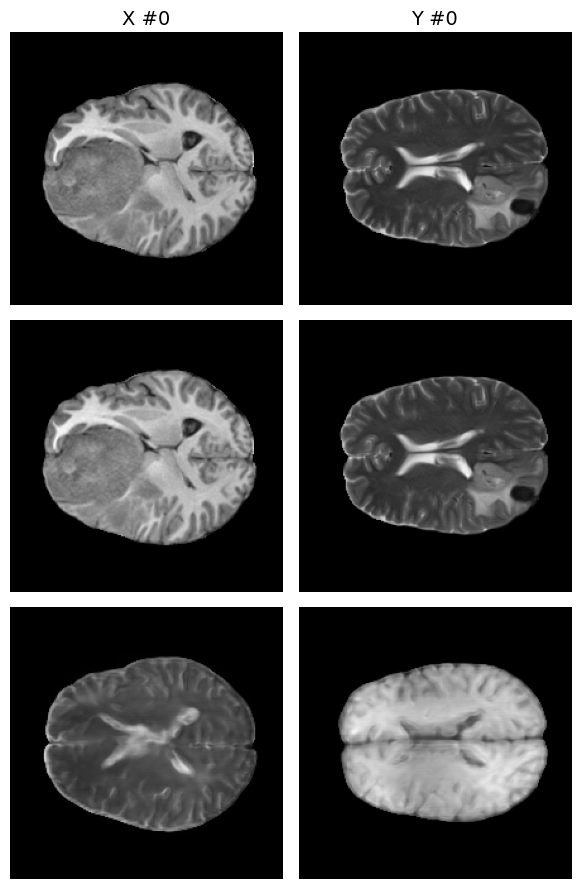

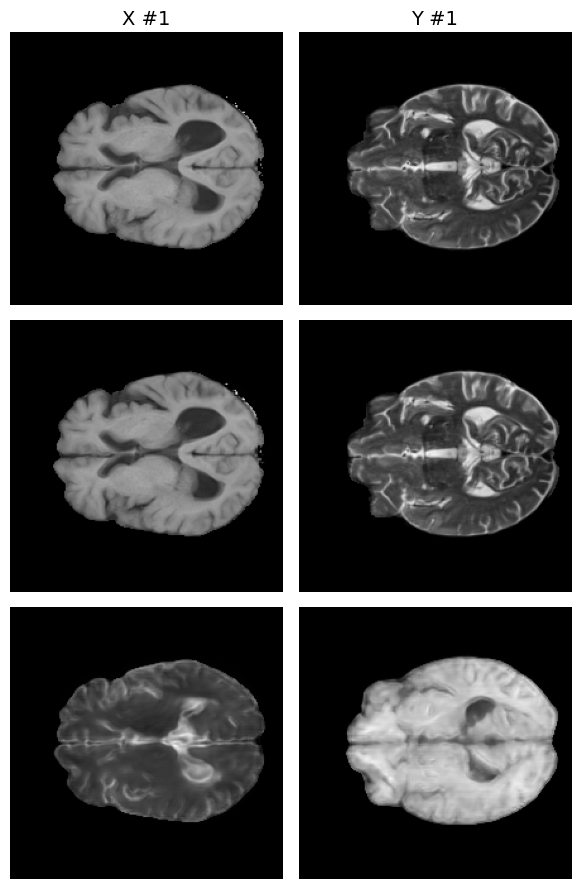

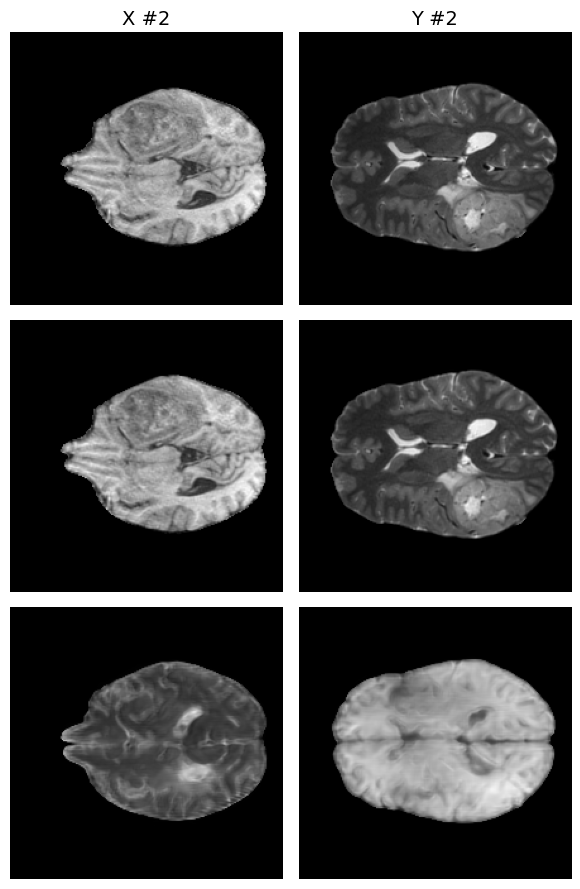

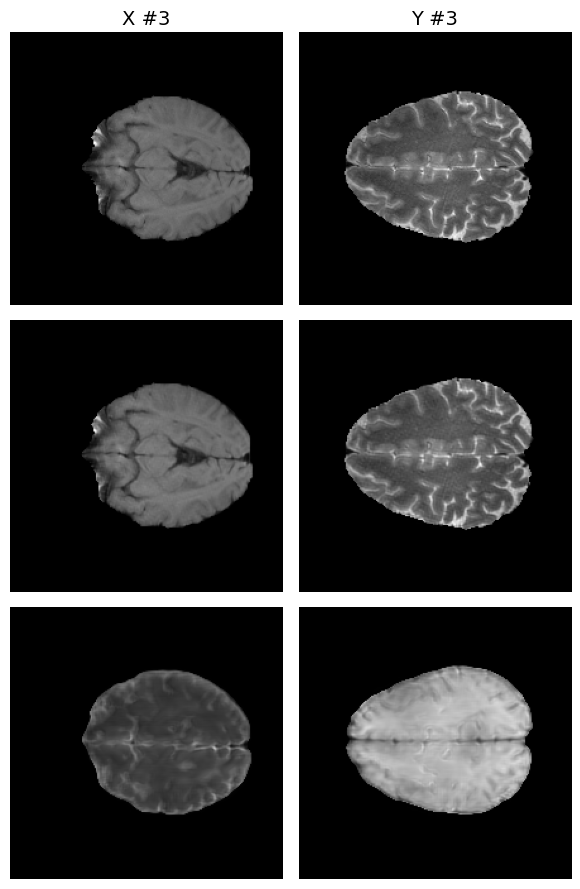

In [ ]:
seed = get_random_seeds()


seed = 7003
# seed_experiments(seed)
# batch_X, batch_Y = get_paired_random_batch(
#     test_bg_dataloader,
#     test_t_dataloader
# )

# seed = 17264
# === Get data ===
# sfe_model.config.data.dataset = 'bloodmnist'
# ds_name = 'brats_multimod_t2f_unpaired'
test_bg_dataloader, test_t_dataloader = configure_datasets(sfe_model.config, test_images=True, seed=seed, shuffle=True)
# loader_bg = DataLoader(
#     dataset_bg,
#     batch_size=config.data.batch_size,
#     shuffle=False
# )

# loader_t = DataLoader(
#     dataset_t,
#     batch_size=config.data.batch_size,
#     shuffle=False
# )
crop_margin = 30   # 每一边裁剪的像素数

# =========================
# 裁剪函数
# =========================
def crop_image(img, margin):
    if margin <= 0:
        return img
    w, h = img.size
    return img.crop((margin, margin, w - margin, h - margin))

h = 0
mg=20
crop_cfg = dict(w_l=mg+h, w_r=mg - h, h_top=mg, h_bot=mg)

%matplotlib inline
inference(
    sfe_model,
    test_bg_dataloader,
    test_t_dataloader,
    idx=3,
    vis_mode="col",
    target_batch_idx=0,
    crop_cfg=crop_cfg
)


In [5]:
sfe_model.config.data.dataset

'brats_multimod_t2f'

In [16]:
# seed = get_random_seeds()
# seed = 2797
# # === Get data ===

# # sfe_model.config.data.dataset = 'octmnist_x3y0'

# test_bg_dataloader, test_t_dataloader = configure_datasets(sfe_model.config, test_images=True, seed=seed, shuffle=True)

# with torch.no_grad():
#     for batch_idx, (batch_bg, batch_t) in tqdm(enumerate(zip(test_bg_dataloader, test_t_dataloader)), total=len(test_bg_dataloader)):

#         X = batch_bg.to(device).float()
#         Y = batch_t.to(device).float()
        
#         X_resh = F.interpolate(X, size=(256, 256), mode="bilinear", align_corners=False)
#         Y_resh = F.interpolate(Y, size=(256, 256), mode="bilinear", align_corners=False)        

        
#         if sfe_model.config.train.train_runner == "fse_editor_cs1s2":
#             # ---- latent decomposition ----
#             c_x, s_x1, s_x2, c_y, s_y1, s_y2 = get_latents_cs1s2(X_resh, Y_resh, sfe_model)
#             # s_x = torch.zeros_like(s_x)
#             recon_w_X = recon_by_latent_w(c_x + s_x1, sfe_model)
#             recon_w_Y = recon_by_latent_w(c_y + s_y2, sfe_model)

#             swap_w_X2Y = recon_by_latent_w(c_x + s_y2, sfe_model)
#             swap_w_Y2X = recon_by_latent_w(c_y + s_x1, sfe_model)

#             recon_f_X = recon_by_delta(X_resh, delta=None, sfe_model=sfe_model)
#             recon_f_Y = recon_by_delta(Y_resh, delta=None, sfe_model=sfe_model)

#             delta_x2y = calculate_delta_by_latent(c_x + s_x1 + s_x2, c_x + s_y1 + s_y2, sfe_model)
#             delta_y2x = calculate_delta_by_latent(c_y + s_y1 + s_y2, c_y + s_x1 + s_x2, sfe_model)
#             swap_f_X2Y = recon_by_delta(X_resh, delta_x2y, sfe_model)
#             swap_f_Y2X = recon_by_delta(Y_resh, delta_y2x, sfe_model)
            
#         elif sfe_model.config.train.train_runner == "fse_editor_cs":
#                             # ---- latent decomposition ----
#             # ---- latent decomposition ----
#             c_x, s_x, c_y, s_y = get_latents_cs(X_resh, Y_resh, sfe_model)
#             s_x = torch.zeros_like(s_x)
#             recon_w_X = recon_by_latent_w(c_x + s_x, sfe_model)
#             recon_w_Y = recon_by_latent_w(c_y + s_y, sfe_model)

#             swap_w_X2Y = recon_by_latent_w(c_x + s_y, sfe_model)
#             swap_w_Y2X = recon_by_latent_w(c_y + s_x, sfe_model)

#             recon_f_X = recon_by_delta(X_resh, delta=None, sfe_model=sfe_model)
#             recon_f_Y = recon_by_delta(Y_resh, delta=None, sfe_model=sfe_model)

#             delta_x2y = calculate_delta_by_latent(c_x + s_x, c_x + s_y, sfe_model)
#             delta_y2x = calculate_delta_by_latent(c_y + s_y, c_y + s_x, sfe_model)
#             swap_f_X2Y = recon_by_delta(X_resh, delta_x2y, sfe_model)
#             swap_f_Y2X = recon_by_delta(Y_resh, delta_y2x, sfe_model)
#         else:
#             raise ValueError(f"Unknown train_runner: {sfe_model.config.train.train_runner}")
        
#         break

# num_pairs = 4
# %matplotlib inline
# for i in range(num_pairs):
#     columns = []

#     # Each column is one image (X or Y), stacked across rows
#     col_X = torch.stack([
#         X[i],                # Input X
#         recon_f_X[i],        # Recon X
#         swap_f_X2Y[i]        # Swap X→Y
#     ], dim=0)

#     col_Y = torch.stack([
#         Y[i],                # Input Y
#         recon_f_Y[i],        # Recon Y
#         swap_f_Y2X[i]        # Swap Y→X
#     ], dim=0)

#     columns = [col_X, col_Y]

#     titles  = [f"X #{i} (seed={seed})", f"Y #{i} (seed={seed})"]

#     visualize_batch_grid(
#         image_batches=columns,   # List of [3, C, H, W]
#         titles=titles,           # Column titles
#         save_path=None           # Or provide path to save
        
#     )
# # Image quantitative evaluation

# Image quantitative evaluation

In [13]:
experiment_name

'brats_multimod_t2w'

In [7]:
seed = get_random_seeds()
#seed = 19298
# === Get data ===
# sfe_model.config.data.dataset = 'bloodmnist'
ds_name = sfe_model.config.data.dataset
test_bg_dataloader, test_t_dataloader = configure_datasets(sfe_model.config, test_images=True, seed=seed, shuffle=False, ds_name =ds_name)

exp_name = f"brats_multimod/{sfe_model.config.train.train_runner}/images/{ds_name}"

save_image_dir = f"/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Med_RESULTS/{exp_name}_Reg"

max_eval_batch = None

if os.path.exists(save_image_dir):
    shutil.rmtree(save_image_dir)

image_paths = ['real_X', 'real_Y', 'recon_w_X', 'recon_w_Y', 'swap_w_Y2X', 'swap_w_X2Y', 'recon_f_X', 'recon_f_Y', 'swap_f_X2Y', 'swap_f_Y2X']

for path in image_paths:
    dir_path = os.path.join(save_image_dir, path)
    os.makedirs(dir_path)


with torch.no_grad():
    for batch_idx, (batch_bg, batch_t) in tqdm(enumerate(zip(test_bg_dataloader, test_t_dataloader)), total=len(test_bg_dataloader)):
        if max_eval_batch is not None and batch_idx >= max_eval_batch:
            break

        X = batch_bg.to(device).float()
        Y = batch_t.to(device).float()
        
        X_resh = F.interpolate(X, size=(256, 256), mode="bilinear", align_corners=False)
        Y_resh = F.interpolate(Y, size=(256, 256), mode="bilinear", align_corners=False)        

        X_resh = F.interpolate(X, size=(256, 256), mode="bilinear", align_corners=False)
        Y_resh = F.interpolate(Y, size=(256, 256), mode="bilinear", align_corners=False)        
        
        if sfe_model.config.train.train_runner == "fse_editor_cs1s2":
            # ---- latent decomposition ----
            c_x, s_x1, s_x2, c_y, s_y1, s_y2 = get_latents_cs1s2(X_resh, Y_resh, sfe_model)
            # s_x = torch.zeros_like(s_x)
            recon_w_X = recon_by_latent_w(c_x + s_x1, sfe_model)
            recon_w_Y = recon_by_latent_w(c_y + s_y2, sfe_model)

            swap_w_X2Y = recon_by_latent_w(c_x + s_y2, sfe_model)
            swap_w_Y2X = recon_by_latent_w(c_y + s_x1, sfe_model)

            recon_f_X = recon_by_delta(X_resh, delta=None, sfe_model=sfe_model)
            recon_f_Y = recon_by_delta(Y_resh, delta=None, sfe_model=sfe_model)

            delta_x2y = calculate_delta_by_latent(c_x + s_x1 + s_x2, c_x + s_y1 + s_y2, sfe_model)
            delta_y2x = calculate_delta_by_latent(c_y + s_y1 + s_y2, c_y + s_x1 + s_x2, sfe_model)
            swap_f_X2Y = recon_by_delta(X_resh, delta_x2y, sfe_model)
            swap_f_Y2X = recon_by_delta(Y_resh, delta_y2x, sfe_model)
            
        elif sfe_model.config.train.train_runner == "fse_editor_cs":
                            # ---- latent decomposition ----
            # ---- latent decomposition ----
            c_x, s_x, c_y, s_y = get_latents_cs(X_resh, Y_resh, sfe_model)
            s_x = torch.zeros_like(s_x)
            recon_w_X = recon_by_latent_w(c_x + s_x, sfe_model)
            recon_w_Y = recon_by_latent_w(c_y + s_y, sfe_model)

            swap_w_X2Y = recon_by_latent_w(c_x + s_y, sfe_model)
            swap_w_Y2X = recon_by_latent_w(c_y + s_x, sfe_model)

            recon_f_X = recon_by_delta(X_resh, delta=None, sfe_model=sfe_model)
            recon_f_Y = recon_by_delta(Y_resh, delta=None, sfe_model=sfe_model)

            delta_x2y = calculate_delta_by_latent(c_x + s_x, c_x + s_y, sfe_model)
            delta_y2x = calculate_delta_by_latent(c_y + s_y, c_y + s_x, sfe_model)
            swap_f_X2Y = recon_by_delta(X_resh, delta_x2y, sfe_model)
            swap_f_Y2X = recon_by_delta(Y_resh, delta_y2x, sfe_model)
        else:
            raise ValueError(f"Unknown train_runner: {sfe_model.config.train.train_runner}")

        # collect (keys align with image_paths)
        images = {
            "real_X": X,
            "real_Y": Y,
            "recon_w_X": recon_w_X,
            "recon_w_Y": recon_w_Y,
            "recon_f_X": recon_f_X,
            "recon_f_Y": recon_f_Y,
            "swap_w_X2Y": swap_w_X2Y,
            "swap_w_Y2X": swap_w_Y2X,
            "swap_f_X2Y": swap_f_X2Y,
            "swap_f_Y2X": swap_f_Y2X,
        }



        # de-normalize / postprocess per tensor (skip None)
        images = {k: (None if v is None else preprocess_image(v)) for k, v in images.items()}

        # save all groups
        B = next(v.size(0) for v in images.values() if v is not None)
        for i in range(B):
            idx = batch_idx * B + i
            for key, tensor in images.items():
                if tensor is None or tensor.ndim != 4 or i >= tensor.size(0):
                    continue
                img_i = tensor[i].detach().cpu().clamp(0, 1)  # safety clamp
                save_image(img_i, os.path.join(save_image_dir, key, f"{idx}.png"))

    print(f"Results images saved to {save_image_dir}")


# num_pairs = 4
# %matplotlib inline
# for i in range(num_pairs):
#     columns = []

#     # Each column is one image (X or Y), stacked across rows
#     col_X = torch.stack([
#         X[i],                # Input X
#         recon_f_X[i],        # Recon X
#         swap_f_X2Y[i]        # Swap X→Y
#     ], dim=0)

#     col_Y = torch.stack([
#         Y[i],                # Input Y
#         recon_f_Y[i],        # Recon Y
#         swap_f_Y2X[i]        # Swap Y→X
#     ], dim=0)

#     columns = [col_X, col_Y]

#     titles  = [f"X #{i} (seed={seed})", f"Y #{i} (seed={seed})"]

#     visualize_batch_grid(
#         image_batches=columns,   # List of [3, C, H, W]
#         titles=titles,           # Column titles
#         save_path=None           # Or provide path to save
#     )


# #
# 14153 19298

Random seed: 4091
Loading dataset
Using dataset: brats_multimod_t2w


100%|██████████| 1250/1250 [14:54<00:00,  1.40it/s]

Results images saved to /home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Med_RESULTS/brats_multimod/fse_editor_cs1s2/images/brats_multimod_t2w_Reg


## Latent separation evaluation

In [8]:
seed = get_random_seeds()
#seed = 19298
# === Get data ===
ds_name = sfe_model.config.data.dataset
test_bg_dataloader, test_t_dataloader = configure_datasets(sfe_model.config, test_images=True, seed=seed, shuffle=False, ds_name =ds_name)

train_data = "latents"

exp_name = f"brats_multimod/{sfe_model.config.train.train_runner}/latents/{ds_name}"

save_image_dir = f"/home/ids/yuhe/Projects/CA_with_GAN/3_code/styleGAN/Med_RESULTS/{exp_name}_Reg"

max_eval_batch = None

if os.path.exists(save_image_dir):
    shutil.rmtree(save_image_dir)

# Prepare directories for saving images
latent_paths = ['latents_x', 'latents_y']

for path in latent_paths:
    dir_path = os.path.join(save_image_dir, path)
    if os.path.exists(dir_path):
            shutil.rmtree(dir_path)
    os.makedirs(dir_path)


sfe_model.method.train()
with torch.no_grad():
    for batch_idx, (batch_bg, batch_t) in tqdm(enumerate(zip(test_bg_dataloader, test_t_dataloader)), total=len(test_bg_dataloader)):
        if max_eval_batch is not None and batch_idx >= max_eval_batch:
            break

        X = batch_bg.to(device).float()
        Y = batch_t.to(device).float()
        
        X_resh = F.interpolate(X, size=(256, 256), mode="bilinear", align_corners=False)
        Y_resh = F.interpolate(Y, size=(256, 256), mode="bilinear", align_corners=False)        
        if sfe_model.config.train.train_runner == "fse_editor_cs1s2":
            c_x, s1_x, s2_x, c_y, s1_y, s2_y = get_latents_cs1s2(X_resh, Y_resh, sfe_model)

            # Group latents for background (x) and target (y)
            latents = {
                "x": {"c": c_x, "s1": s1_x, "s2": s2_x},
                "y": {"c": c_y, "s1": s1_y, "s2": s2_y},
            }
        elif sfe_model.config.train.train_runner == "fse_editor_cs":
            c_x, s_x, c_y, s_y = get_latents_cs(X_resh, Y_resh, sfe_model)

            # Group latents for background (x) and target (y)
            latents = {
                "x": {"c": c_x, "s": s_x},
                "y": {"c": c_y, "s": s_y},
            }            
        # Save latents per sample
        batch_size = X.size(0)
        for i in range(batch_size):
            idx = batch_idx * batch_size + i
            for key in ["x", "y"]:
                save_path = os.path.join(save_image_dir, f"latents_{key}", f"latent_{key}_{idx}.pt")
                torch.save({k: v[i].cpu() for k, v in latents[key].items()}, save_path)


Random seed: 16130
Loading dataset
Using dataset: brats_multimod_t2w


100%|██████████| 1250/1250 [02:28<00:00,  8.42it/s]


## Interpolation

In [ ]:
# import torch
# import matplotlib.pyplot as plt
# seed = get_random_seeds()
# #seed = 12830
# # === Get data ===

# test_bg_dataloader, test_t_dataloader = configure_datasets(sfe_model.config, test_images=True, seed=seed, shuffle=True)
# # === Alpha Range ===
# alphas_x = torch.linspace(0, 1, steps=5)
# alphas_y = torch.linspace(0, 1, steps=5)
# # alphas_x = alpha#[0.0000, 0.2000, 0.4000, 0.6000, 1.0000]
# # alphas_y = alpha#[0.0000, 0.2000, 0.4000, 0.6000, 1.0000]

# # === Prepare reconstructions ===
# recon_w_X_alpha = []
# recon_w_Y_alpha = []
# recon_f_X_alpha = []
# recon_f_Y_alpha = []

# with torch.no_grad():
#     for batch_idx, (batch_bg, batch_t) in tqdm(enumerate(zip(test_bg_dataloader, test_t_dataloader)), total=len(test_bg_dataloader)):

        
#         X = batch_bg.to(device).float()
#         Y = batch_t.to(device).float()
        
#         X_resh = F.interpolate(X, size=(256, 256), mode="bilinear", align_corners=False)
#         Y_resh = F.interpolate(Y, size=(256, 256), mode="bilinear", align_corners=False)        

#         # === Add Real Images First ===
#         recon_w_X_alpha.append(X_resh)
#         recon_w_Y_alpha.append(Y_resh)
#         recon_f_X_alpha.append(X_resh)
#         recon_f_Y_alpha.append(Y_resh)

#         c_x, s_x, c_y, s_y = get_latents_cs(X_resh, Y_resh, sfe_model)
#         s_x = torch.zeros_like(s_x)
        
#         recon_w_X = recon_by_latent_w(c_x + s_x, sfe_model)
#         recon_w_Y = recon_by_latent_w(c_y + s_y, sfe_model)
#         recon_f_X = recon_by_delta(X_resh, delta=None, sfe_model=sfe_model)
#         recon_f_Y = recon_by_delta(Y_resh, delta=None, sfe_model=sfe_model)

#         for alpha_x, alpha_y in zip(alphas_x, alphas_y):
#         #     s_interp_x2y = (1 - alpha_x) * s_x + alpha_x * s_y
#         #     s_interp_y2x = (1 - alpha_y) * s_y + alpha_y * s_x
#         #     recon_w_X_alpha.append(recon_by_latent_w(c_x + s_interp_x2y))
#         #     recon_w_Y_alpha.append(recon_by_latent_w(c_y + s_interp_y2x))
        
#             delta_x2y = calculate_delta_by_latent(c_x + s_x, c_x + s_y, sfe_model)
#             delta_y2x = calculate_delta_by_latent(c_y + s_y, c_y + s_x, sfe_model)
            
#             swap_f_X2Y = recon_by_delta(X_resh, alpha_x * delta_x2y, sfe_model=sfe_model)
#             swap_f_Y2X = recon_by_delta(Y_resh, alpha_y * delta_y2x, sfe_model=sfe_model)

#             recon_f_X_alpha.append(swap_f_X2Y)
#             recon_f_Y_alpha.append(swap_f_Y2X)
        
#         break

# titles_x = [f"real (seed={seed})"] + [f"α={a:.1f}" for a in alphas_x]
# titles_y = [f"real (seed={seed})"] + [f"α={a:.1f}" for a in alphas_y]

# # === Helper: Convert tensor to image ===
# def tensor_to_img(t):
#     t = ((t.clamp(-1, 1) + 1) / 2).detach().cpu()
#     if t.shape[0] == 1:
#         return t.squeeze(0).numpy()
#     return t.permute(1, 2, 0).numpy()

# # === Visualization ===
# num_images = len(recon_f_X_alpha)
# col_spacing = 0.0
# title_height = 0.05
# total_width = 1.0
# idx = 3
# img_width = (total_width - (num_images - 1) * col_spacing) / num_images


# %matplotlib inline
# # --- FIGURE 1: Y1 Row ---
# fig_y1 = plt.figure(figsize=(num_images * 2.2, 2.5))
# for i in range(num_images):
#     left = i * (img_width + col_spacing)
#     width = img_width

#     ax = fig_y1.add_axes([left, 0, width, 1 - title_height])
#     img = tensor_to_img(recon_f_X_alpha[i][idx])
#     ax.imshow(img)
#     ax.axis("off")
#     ax.set_title(titles_x[i], fontsize=20, pad=2)
    

# plt.show()

# # --- FIGURE 2: Y2 Row ---
# fig_y2 = plt.figure(figsize=(num_images * 2.2, 2.5))
# for i in range(num_images):
#     left = i * (img_width + col_spacing)
#     width = img_width

#     ax = fig_y2.add_axes([left, 0, width, 1])
#     img = tensor_to_img(recon_f_Y_alpha[i][idx])
#     ax.imshow(img)
#     ax.axis("off")
#     ax.set_title(titles_y[i], fontsize=20, pad=2)

# plt.show()